# JPEG-LS Regular-Mode Python Implementation Notebook

This notebook replaces the terminal flow:

```bash
python -m pip install -r requirements.txt
bash scripts/run_python_impl.sh
```

Run this notebook from top to bottom. It will:

1. check/install Python dependencies inside the notebook kernel,
2. create `images/`, `data/`, and `plots/`,
3. generate synthetic test images,
4. load the two required real images if present:
   - `images/two macaws.png`
   - `images/whitewater rafting.png`
5. convert images to grayscale `.mem`,
6. run the JPEG-LS regular-mode inspired Python golden encoder/decoder,
7. verify lossless reconstruction,
8. generate `data/python_results.csv`,
9. generate `submitted_results.json`,
10. generate plots in `plots/`.

Scope: 8-bit grayscale, lossless, regular-mode inspired JPEG-LS datapath only. This is not a full JPEG-LS file-container encoder.


In [3]:
# Cell 1 — Notebook-local dependency check / install
# This runs inside the notebook, not in a separate terminal.

import importlib.util

required_packages = {
    "numpy": "numpy",
    "PIL": "Pillow",
    "matplotlib": "matplotlib",
    "pandas": "pandas",
}

missing = [pip_name for import_name, pip_name in required_packages.items()
           if importlib.util.find_spec(import_name) is None]

if missing:
    print("Installing missing packages in the current notebook kernel:", missing)
    get_ipython().run_line_magic("pip", "install " + " ".join(missing))
else:
    print("All required packages are already installed.")


All required packages are already installed.


In [4]:
# Cell 2 — Imports and output folders

from __future__ import annotations

import csv
import json
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path(".").resolve()
IMAGE_DIR = ROOT / "images"
DATA_DIR = ROOT / "data"
PLOTS_DIR = ROOT / "plots"

IMAGE_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("Place real images here:")
print(" ", IMAGE_DIR / "two macaws.png")
print(" ", IMAGE_DIR / "whitewater rafting.png")


ROOT: /home/yh6341/9463_04172026_1/hwdesign/labs/jjppeeggllss
Place real images here:
  /home/yh6341/9463_04172026_1/hwdesign/labs/jjppeeggllss/images/two macaws.png
  /home/yh6341/9463_04172026_1/hwdesign/labs/jjppeeggllss/images/whitewater rafting.png


In [5]:
# Cell 3 — Bitstream utilities

class BitWriter:
    """MSB-first bit writer used by the software golden model."""

    def __init__(self) -> None:
        self._bytes = bytearray()
        self._cur = 0
        self._nbits_cur = 0
        self._total_bits = 0

    def write_bit(self, bit: int) -> None:
        bit = 1 if bit else 0
        self._cur = (self._cur << 1) | bit
        self._nbits_cur += 1
        self._total_bits += 1
        if self._nbits_cur == 8:
            self._bytes.append(self._cur & 0xFF)
            self._cur = 0
            self._nbits_cur = 0

    def write_bits(self, value: int, nbits: int) -> None:
        if nbits < 0:
            raise ValueError("nbits must be nonnegative")
        if nbits == 0:
            return
        if value < 0 or value >= (1 << nbits):
            raise ValueError(f"value={value} does not fit in {nbits} bits")
        for i in range(nbits - 1, -1, -1):
            self.write_bit((value >> i) & 1)

    def write_unary(self, q: int) -> None:
        if q < 0:
            raise ValueError("unary quotient must be nonnegative")
        for _ in range(q):
            self.write_bit(0)
        self.write_bit(1)

    def bit_length(self) -> int:
        return self._total_bits

    def to_bytes(self) -> bytes:
        out = bytearray(self._bytes)
        if self._nbits_cur:
            out.append((self._cur << (8 - self._nbits_cur)) & 0xFF)
        return bytes(out)


@dataclass
class BitReader:
    """MSB-first bit reader for the project bitstream format."""

    data: bytes
    nbits: int

    def __post_init__(self) -> None:
        if self.nbits < 0 or self.nbits > len(self.data) * 8:
            raise ValueError("invalid nbits for provided data")
        self._pos = 0

    def read_bit(self) -> int:
        if self._pos >= self.nbits:
            raise EOFError("no bits left")
        byte = self.data[self._pos // 8]
        shift = 7 - (self._pos % 8)
        bit = (byte >> shift) & 1
        self._pos += 1
        return bit

    def read_bits(self, nbits: int) -> int:
        value = 0
        for _ in range(nbits):
            value = (value << 1) | self.read_bit()
        return value

    def read_unary(self) -> int:
        q = 0
        while True:
            b = self.read_bit()
            if b == 1:
                return q
            q += 1


def save_bytes_mem(data: bytes, path: str | Path) -> None:
    Path(path).write_text("\n".join(f"{b:02X}" for b in data) + "\n", encoding="utf-8")


def load_bytes_mem(path: str | Path) -> bytes:
    values = []
    for raw in Path(path).read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("//") or line.startswith("#"):
            continue
        values.append(int(line, 16))
    return bytes(values)


In [6]:
# Cell 4 — Image conversion and synthetic test-image utilities

def load_image_as_grayscale(path: str | Path) -> np.ndarray:
    img = Image.open(path).convert("L")
    arr = np.asarray(img, dtype=np.uint8)
    if arr.ndim != 2:
        raise ValueError(f"Expected grayscale 2-D array, got shape={arr.shape}")
    return arr


def save_mem(image: np.ndarray, mem_path: str | Path, include_dims_header: bool = False) -> None:
    arr = np.asarray(image)
    if arr.ndim != 2:
        raise ValueError(f"Expected shape (H, W), got {arr.shape}")
    if arr.dtype != np.uint8:
        raise TypeError(f"Expected dtype uint8, got {arr.dtype}")

    lines = []
    if include_dims_header:
        h, w = arr.shape
        lines.append(f"// HEIGHT={h}")
        lines.append(f"// WIDTH={w}")
    lines.extend(f"{int(v):02X}" for v in arr.reshape(-1))
    Path(mem_path).write_text("\n".join(lines) + "\n", encoding="utf-8")


def write_dims_file(image: np.ndarray, path: str | Path) -> None:
    h, w = np.asarray(image).shape
    Path(path).write_text(f"{h} {w}\n", encoding="utf-8")


def make_constant(width: int, height: int, value: int) -> np.ndarray:
    return np.full((height, width), np.uint8(value), dtype=np.uint8)


def make_horizontal_gradient(width: int, height: int) -> np.ndarray:
    row = np.linspace(0, 255, width, dtype=np.uint8)
    return np.tile(row[None, :], (height, 1))


def make_vertical_gradient(width: int, height: int) -> np.ndarray:
    col = np.linspace(0, 255, height, dtype=np.uint8)
    return np.tile(col[:, None], (1, width))


def make_checkerboard(width: int, height: int, block: int = 1) -> np.ndarray:
    yy, xx = np.indices((height, width))
    return (((yy // block + xx // block) & 1) * 255).astype(np.uint8)


def make_random(width: int, height: int, seed: int = 1) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.integers(0, 256, size=(height, width), dtype=np.uint8)


def make_pattern(name: str, width: int = 8, height: int = 8) -> np.ndarray:
    if name == "all_zero":
        return make_constant(width, height, 0)
    if name == "constant_128":
        return make_constant(width, height, 128)
    if name == "horizontal_gradient":
        return make_horizontal_gradient(width, height)
    if name == "vertical_gradient":
        return make_vertical_gradient(width, height)
    if name == "checkerboard":
        return make_checkerboard(width, height, block=1)
    if name == "random":
        return make_random(width, height, seed=1)
    raise ValueError(f"unknown pattern: {name}")


SYNTHETIC_PATTERNS = [
    "all_zero",
    "constant_128",
    "horizontal_gradient",
    "vertical_gradient",
    "checkerboard",
    "random",
]


In [7]:
# Cell 5 — JPEG-LS regular-mode inspired Python golden model

RESET = 64
MIN_C = -128
MAX_C = 127

# Compact RTL-friendly context quantizer:
# 9 bins per gradient, 9^3 = 729 contexts.
CONTEXT_BINS = 9
NUM_CONTEXTS = CONTEXT_BINS ** 3


@dataclass
class EncodeResult:
    bitstream_bytes: bytes
    nbits: int
    trace: dict[str, np.ndarray]

    @property
    def nbytes(self) -> int:
        return len(self.bitstream_bytes)


@dataclass
class DecodeResult:
    image: np.ndarray
    trace: dict[str, np.ndarray]


def clip_u8(v: int) -> int:
    return 0 if v < 0 else 255 if v > 255 else int(v)


def med_predictor(a: int, b: int, c: int) -> int:
    """JPEG-LS median-edge detector predictor."""
    if c >= max(a, b):
        return min(a, b)
    if c <= min(a, b):
        return max(a, b)
    return a + b - c


def quantize_gradient(g: int) -> int:
    """Quantize a local gradient into one of nine bins [-4, 4]."""
    if g <= -128:
        return -4
    if g <= -64:
        return -3
    if g <= -32:
        return -2
    if g <= -8:
        return -1
    if g < 8:
        return 0
    if g < 32:
        return 1
    if g < 64:
        return 2
    if g < 128:
        return 3
    return 4


def context_id_from_neighbors(a: int, b: int, c: int, d: int) -> int:
    # C B D
    # A X
    g1 = d - b
    g2 = b - c
    g3 = c - a
    q1 = quantize_gradient(g1)
    q2 = quantize_gradient(g2)
    q3 = quantize_gradient(g3)
    return (q1 + 4) * 81 + (q2 + 4) * 9 + (q3 + 4)


def map_error(err: int) -> int:
    return 2 * err if err >= 0 else -2 * err - 1


def unmap_error(merr: int) -> int:
    return merr // 2 if (merr & 1) == 0 else -((merr + 1) // 2)


def golomb_k(A: int, N: int) -> int:
    k = 0
    while (N << k) < A:
        k += 1
    return k


def neighbors(img: np.ndarray, y: int, x: int) -> tuple[int, int, int, int]:
    a = int(img[y, x - 1]) if x > 0 else 0
    b = int(img[y - 1, x]) if y > 0 else 0
    c = int(img[y - 1, x - 1]) if (x > 0 and y > 0) else 0
    d = int(img[y - 1, x + 1]) if (y > 0 and x + 1 < img.shape[1]) else b
    return a, b, c, d


class JPEGLSRegularState:
    def __init__(self) -> None:
        self.A = np.full(NUM_CONTEXTS, 4, dtype=np.int64)
        self.B = np.zeros(NUM_CONTEXTS, dtype=np.int64)
        self.C = np.zeros(NUM_CONTEXTS, dtype=np.int64)
        self.N = np.ones(NUM_CONTEXTS, dtype=np.int64)

    def correct_predictor(self, px: int, q: int) -> int:
        return clip_u8(px + int(self.C[q]))

    def update_context(self, q: int, err: int) -> None:
        self.B[q] += err
        self.A[q] += abs(err)

        if self.B[q] <= -self.N[q]:
            self.B[q] += self.N[q]
            if self.C[q] > MIN_C:
                self.C[q] -= 1
            if self.B[q] <= -self.N[q]:
                self.B[q] = -self.N[q] + 1
        elif self.B[q] > 0:
            self.B[q] -= self.N[q]
            if self.C[q] < MAX_C:
                self.C[q] += 1
            if self.B[q] > 0:
                self.B[q] = 0

        if self.N[q] == RESET:
            self.A[q] >>= 1
            self.B[q] >>= 1
            self.N[q] >>= 1

        self.N[q] += 1


def encode_image(image: np.ndarray) -> EncodeResult:
    img = np.asarray(image)
    if img.ndim != 2:
        raise ValueError(f"expected grayscale image shape (H, W), got {img.shape}")
    if img.dtype != np.uint8:
        raise TypeError(f"expected uint8 image, got {img.dtype}")

    h, w = img.shape
    st = JPEGLSRegularState()
    writer = BitWriter()

    pred = np.zeros((h, w), dtype=np.int16)
    err = np.zeros((h, w), dtype=np.int16)
    merr = np.zeros((h, w), dtype=np.int32)
    kmap = np.zeros((h, w), dtype=np.uint8)
    ctx_id_map = np.zeros((h, w), dtype=np.uint16)
    code_len = np.zeros((h, w), dtype=np.uint16)

    for y in range(h):
        for x in range(w):
            a, b, c, d = neighbors(img, y, x)
            q = context_id_from_neighbors(a, b, c, d)
            px = st.correct_predictor(med_predictor(a, b, c), q)

            errval = int(img[y, x]) - px
            merrval = map_error(errval)
            k = golomb_k(int(st.A[q]), int(st.N[q]))

            unary_q = merrval >> k
            rem = merrval & ((1 << k) - 1) if k > 0 else 0
            writer.write_unary(unary_q)
            if k > 0:
                writer.write_bits(rem, k)

            pred[y, x] = px
            err[y, x] = errval
            merr[y, x] = merrval
            kmap[y, x] = k
            ctx_id_map[y, x] = q
            code_len[y, x] = unary_q + 1 + k

            st.update_context(q, errval)

    trace = {
        "pred": pred,
        "err": err,
        "merr": merr,
        "k": kmap,
        "ctx_id": ctx_id_map,
        "code_len": code_len,
    }
    return EncodeResult(writer.to_bytes(), writer.bit_length(), trace)


def decode_image(bitstream: bytes, *, nbits: int, height: int, width: int) -> DecodeResult:
    reader = BitReader(bitstream, nbits)
    out = np.zeros((height, width), dtype=np.uint8)
    st = JPEGLSRegularState()

    pred = np.zeros((height, width), dtype=np.int16)
    err = np.zeros((height, width), dtype=np.int16)
    merr = np.zeros((height, width), dtype=np.int32)
    kmap = np.zeros((height, width), dtype=np.uint8)
    ctx_id_map = np.zeros((height, width), dtype=np.uint16)

    for y in range(height):
        for x in range(width):
            a, b, c, d = neighbors(out, y, x)
            q = context_id_from_neighbors(a, b, c, d)
            px = st.correct_predictor(med_predictor(a, b, c), q)
            k = golomb_k(int(st.A[q]), int(st.N[q]))

            unary_q = reader.read_unary()
            rem = reader.read_bits(k) if k > 0 else 0
            merrval = (unary_q << k) | rem
            errval = unmap_error(merrval)
            sample = px + errval
            if not 0 <= sample <= 255:
                raise ValueError(f"decoded sample out of range at y={y}, x={x}: {sample}")

            out[y, x] = np.uint8(sample)
            pred[y, x] = px
            err[y, x] = errval
            merr[y, x] = merrval
            kmap[y, x] = k
            ctx_id_map[y, x] = q

            st.update_context(q, errval)

    trace = {
        "pred": pred,
        "err": err,
        "merr": merr,
        "k": kmap,
        "ctx_id": ctx_id_map,
    }
    return DecodeResult(out, trace)


In [8]:
# Cell 6 — Output helpers

def save_trace_npz(trace: dict[str, np.ndarray], path: str | Path) -> None:
    np.savez_compressed(path, **trace)


def save_trace_csv(trace: dict[str, np.ndarray], path: str | Path, max_rows: int | None = None) -> None:
    keys = list(trace.keys())
    h, w = next(iter(trace.values())).shape
    rows_written = 0
    with Path(path).open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["y", "x", *keys])
        writer.writeheader()
        for y in range(h):
            for x in range(w):
                row = {"y": y, "x": x}
                for key in keys:
                    row[key] = int(trace[key][y, x])
                writer.writerow(row)
                rows_written += 1
                if max_rows is not None and rows_written >= max_rows:
                    return


def encode_array_to_outputs(img: np.ndarray, name: str, input_label: str) -> dict:
    h, w = img.shape
    result = encode_image(img)
    dec = decode_image(result.bitstream_bytes, nbits=result.nbits, height=h, width=w)

    ok = bool(np.array_equal(img, dec.image))
    max_abs_diff = int(np.max(np.abs(img.astype(np.int16) - dec.image.astype(np.int16))))

    prefix = DATA_DIR / name

    save_mem(img, f"{prefix}.mem")
    write_dims_file(img, f"{prefix}_dims.txt")
    save_bytes_mem(result.bitstream_bytes, f"{prefix}_compressed.mem")
    Path(f"{prefix}.bin").write_bytes(result.bitstream_bytes)
    save_trace_npz(result.trace, f"{prefix}_trace.npz")
    save_trace_csv(result.trace, f"{prefix}_trace_head.csv", max_rows=256)

    Image.fromarray(img, mode="L").save(f"{prefix}_gray.png")
    Image.fromarray(dec.image, mode="L").save(f"{prefix}_decoded.png")

    sidecar = {
        "name": name,
        "input_label": input_label,
        "height": int(h),
        "width": int(w),
        "input_bytes": int(h * w),
        "compressed_bytes": int(len(result.bitstream_bytes)),
        "valid_bits": int(result.nbits),
        "bits_per_pixel": float(result.nbits / (h * w)),
        "compression_ratio_input_over_output": float((h * w) / max(1, len(result.bitstream_bytes))),
        "lossless_decode_match": ok,
        "max_abs_diff": max_abs_diff,
        "regular_mode_only": True,
        "grayscale_8bit_only": True,
    }

    Path(f"{prefix}_summary.json").write_text(json.dumps(sidecar, indent=2) + "\n", encoding="utf-8")
    return sidecar


In [9]:
# Cell 7 — Generate vectors and run all Python tests

summaries = []
missing_real_images = []

# Synthetic regression images
for pattern in SYNTHETIC_PATTERNS:
    img = make_pattern(pattern, width=8, height=8)
    png_path = IMAGE_DIR / f"{pattern}_8x8.png"
    Image.fromarray(img, mode="L").save(png_path)
    summaries.append(encode_array_to_outputs(img, f"{pattern}_8x8", str(png_path)))

# Required real images
real_images = [
    IMAGE_DIR / "two macaws.png",
    IMAGE_DIR / "whitewater rafting.png",
]

for path in real_images:
    if path.exists():
        img = load_image_as_grayscale(path)
        name = path.stem.replace(" ", "_")
        summaries.append(encode_array_to_outputs(img, name, str(path)))
    else:
        missing_real_images.append(str(path))

# Build result CSV
rows = []
for s in summaries:
    rows.append({
        "test_name": s["name"],
        "height": s["height"],
        "width": s["width"],
        "input_bytes": s["input_bytes"],
        "compressed_bytes": s["compressed_bytes"],
        "valid_bits": s["valid_bits"],
        "bits_per_pixel": s["bits_per_pixel"],
        "compression_ratio": s["compression_ratio_input_over_output"],
        "lossless_decode_match": s["lossless_decode_match"],
        "max_abs_diff": s["max_abs_diff"],
        "result": "PASS" if s["lossless_decode_match"] else "FAIL",
    })

df = pd.DataFrame(rows)
df.to_csv(DATA_DIR / "python_results.csv", index=False)

synthetic_count = len([r for r in rows if r["test_name"] not in {"two_macaws", "whitewater_rafting"}])
real_image_count = len([r for r in rows if r["test_name"] in {"two_macaws", "whitewater_rafting"}])
all_lossless = bool(df["lossless_decode_match"].all()) if not df.empty else False

python_score = 0
if synthetic_count >= 6:
    python_score += 4
if all_lossless and len(rows) > 0:
    python_score += 4
if real_image_count == 2:
    python_score += 2

status = "PASS" if python_score == 10 else "PARTIAL"
if not rows or not all_lossless:
    status = "FAIL"

submitted = {
    "project": "JPEG-LS regular-mode FPGA IP Python golden-reference notebook stage",
    "python_implementation": {
        "score": python_score,
        "max_score": 10,
        "status": status,
        "synthetic_tests": synthetic_count,
        "real_image_tests": real_image_count,
        "required_real_images": [
            "images/two macaws.png",
            "images/whitewater rafting.png",
        ],
        "missing_real_images": missing_real_images,
        "all_lossless_decode_match": all_lossless,
        "results_csv": "data/python_results.csv",
    },
    "notes": [
        "All Python implementation steps were executed inside this notebook.",
        "Python is the golden reference model and vector generator.",
        "The generated .mem, .json, .csv, .npz, and plot files are intended for later RTL/HLS verification.",
        "This notebook implements 8-bit grayscale, lossless, regular-mode inspired JPEG-LS only.",
    ],
    "tests": rows,
}

Path("submitted_results.json").write_text(json.dumps(submitted, indent=2) + "\n", encoding="utf-8")
Path(DATA_DIR / "python_vector_summary.json").write_text(
    json.dumps({"summaries": summaries, "missing_real_images": missing_real_images}, indent=2) + "\n",
    encoding="utf-8",
)

print(json.dumps(submitted["python_implementation"], indent=2))
display(df)


{
  "score": 10,
  "max_score": 10,
  "status": "PASS",
  "synthetic_tests": 6,
  "real_image_tests": 2,
  "required_real_images": [
    "images/two macaws.png",
    "images/whitewater rafting.png"
  ],
  "missing_real_images": [],
  "all_lossless_decode_match": true,
  "results_csv": "data/python_results.csv"
}


,test_name,height,width,input_bytes,compressed_bytes,valid_bits,bits_per_pixel,compression_ratio,lossless_decode_match,max_abs_diff,result
0,all_zero_8x8,8,8,64,9,68,1.062500,7.111111,True,0,PASS
1,constant_128_8x8,8,8,64,39,306,4.781250,1.641026,True,0,PASS
2,horizontal_gradient_8x8,8,8,64,25,196,3.062500,2.560000,True,0,PASS
3,vertical_gradient_8x8,8,8,64,29,225,3.515625,2.206897,True,0,PASS
4,checkerboard_8x8,8,8,64,216,1721,26.890625,0.296296,True,0,PASS
5,random_8x8,8,8,64,371,2961,46.265625,0.172507,True,0,PASS
6,two_macaws,512,768,393216,180903,1447224,3.680481,2.173629,True,0,PASS
7,whitewater_rafting,512,768,393216,244120,1952957,4.966626,1.610749,True,0,PASS


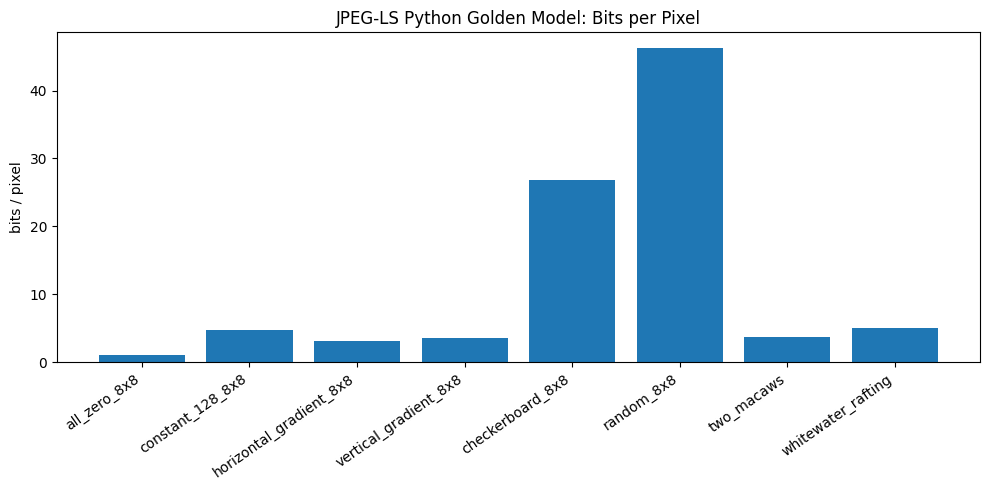

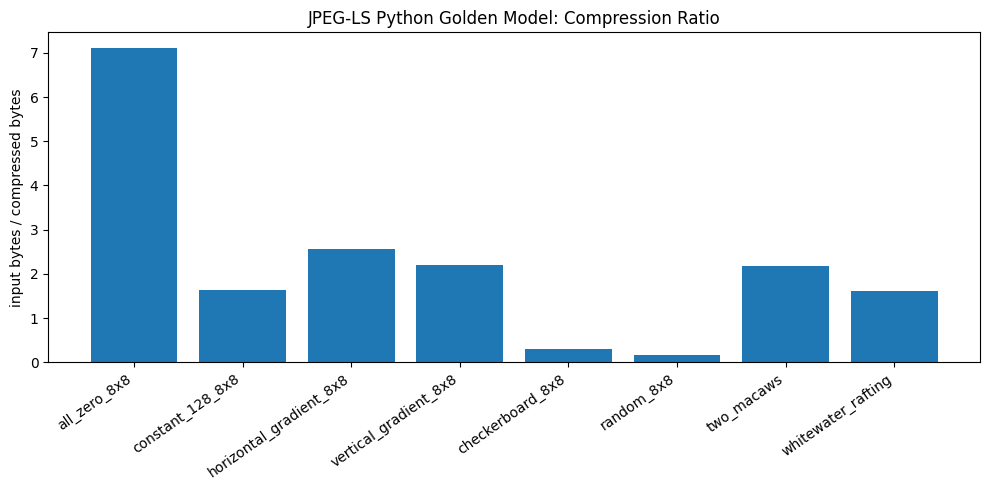

Generated:
  submitted_results.json exists = True
  data/python_results.csv exists = True
  plots/bits_per_pixel.png exists = True
  plots/compression_ratio.png exists = True


In [10]:
# Cell 8 — Generate plots

if not df.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(df["test_name"], df["bits_per_pixel"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("bits / pixel")
    plt.title("JPEG-LS Python Golden Model: Bits per Pixel")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "bits_per_pixel.png", dpi=160)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(df["test_name"], df["compression_ratio"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("input bytes / compressed bytes")
    plt.title("JPEG-LS Python Golden Model: Compression Ratio")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "compression_ratio.png", dpi=160)
    plt.show()

print("Generated:")
for path in [
    "submitted_results.json",
    "data/python_results.csv",
    "plots/bits_per_pixel.png",
    "plots/compression_ratio.png",
]:
    print(" ", path, "exists =", Path(path).exists())


In [11]:
# Cell 9 — Quick inspect generated files

print("Data files:")
for p in sorted(DATA_DIR.glob("*"))[:60]:
    print(" ", p)

print("\nPlot files:")
for p in sorted(PLOTS_DIR.glob("*")):
    print(" ", p)

print("\nsubmitted_results.json:")
print(Path("submitted_results.json").read_text(encoding="utf-8")[:2000])


Data files:
  /home/yh6341/9463_04172026_1/hwdesign/labs/jjppeeggllss/data/all_zero_8x8.bin
  /home/yh6341/9463_04172026_1/hwdesign/labs/jjppeeggllss/data/all_zero_8x8.mem
  /home/yh6341/9463_04172026_1/hwdesign/labs/jjppeeggllss/data/all_zero_8x8_compressed.mem
  /home/yh6341/9463_04172026_1/hwdesign/labs/jjppeeggllss/data/all_zero_8x8_decoded.png
  /home/yh6341/9463_04172026_1/hwdesign/labs/jjppeeggllss/data/all_zero_8x8_dims.txt
  /home/yh6341/9463_04172026_1/hwdesign/labs/jjppeeggllss/data/all_zero_8x8_gray.png
  /home/yh6341/9463_04172026_1/hwdesign/labs/jjppeeggllss/data/all_zero_8x8_summary.json
  /home/yh6341/9463_04172026_1/hwdesign/labs/jjppeeggllss/data/all_zero_8x8_trace.npz
  /home/yh6341/9463_04172026_1/hwdesign/labs/jjppeeggllss/data/all_zero_8x8_trace_head.csv
  /home/yh6341/9463_04172026_1/hwdesign/labs/jjppeeggllss/data/checkerboard_8x8.bin
  /home/yh6341/9463_04172026_1/hwdesign/labs/jjppeeggllss/data/checkerboard_8x8.mem
  /home/yh6341/9463_04172026_1/hwdesign/labs/

## README Change Needed

In your `README.md`, replace the terminal instructions with:

```markdown
## How to Run the Python Implementation

Open `stage2_jpegls_python_implementation_all_in_one.ipynb` and run all cells from top to bottom.

The notebook performs dependency checking, image conversion, synthetic-vector generation, JPEG-LS regular-mode Python encoding/decoding, lossless verification, CSV/JSON generation, and plot generation.

Required real images:

```text
images/two macaws.png
images/whitewater rafting.png
```

Generated evidence:

```text
submitted_results.json
data/python_results.csv
data/*_summary.json
data/*_compressed.mem
data/*_trace.npz
data/*_trace_head.csv
plots/bits_per_pixel.png
plots/compression_ratio.png
```
```
